In [1]:
#Appropriate Folder Setup

#1. Create two new folders specifically named 'Ham' and 'Spam'. At the end, these will be subfolders placed in the main 'Email' folder. 

#2. Download each zipfile for each subset of the data from https://spamassassin.apache.org/old/publiccorpus/

#3 Extract each zip file for each subset into the corresponding 'Ham' or 'Spam' folder, while ignoring the detection difficulty aspect of the subsets 

#4  Once all the data has been placed in the appropriate subfolder, create a new folder specifically titled "Email",  and place the two 
#subfolders into the 'Email' folder. 

#5 You guys must also run the following two lines of code once 
# nltk.download('punkt')
# nltk.download('stopwords')

#These download the Punkt tokenizer models, as well as a collection of stopwords, and are both essential resources for NLTK (Natural Language Toolkit)

#Outline of Code (STEPS)



#

#1. READ THROUGH FILE AND STORE DATA by navigating through folder structure with 'os' walk function, and then




In [2]:
# Step 1: Importing Neccesary 
import os #Importing os to navigate through the "Email" folder and get all files  
import pandas as pd
import nltk # Importing nltk, which is used a lot for preprocessing the data
from nltk.stem.porter import PorterStemmer #Importing PorterStemmer, used for "stemming" or reducing words to their base
from nltk.corpus import stopwords 
import string
from collections import Counter # Importing counter function for when we need to get most common words from  both Ham and Spam emails
from bs4 import BeautifulSoup #Importing BeautifulSoup to extract HTML content that we won't want to include in our "content" variable


# NEED to run these next 2 lines of code below ONCE to tokenize the text, and remove stopwords (words like "and",or "the" that aren't meaningful)
# nltk.download('punkt')
# nltk.download('stopwords')


#STEP 1: (Preprocessing) Stemming the words to 

#Initializing the PorterStemmer, used for "stemming" or reducing words to their base. Enables matching between diff types of same word 
#(ex: running, ran, runner all reduced to run). Once we have this, we can use "ps.stem()" later on 
ps = PorterStemmer()



#Function for preprocessing text, which standardizes text (LOWERCASING, TOKENIZING, REMOVING USELESS TEXT). Standardization ALSO
#enables matching of different types of same word. 
def transform_text(text):
    # Transforming all text to lowercase (so all variations of a given word are considered the same)
    text = text.lower()
    
    # Tokenizing using nltk, which helps structure the text, specifically since 
    text = nltk.word_tokenize(text)
    
    # Starting stopword removal process by by iterating through the token, and appending to empty list all alphanumeric values
    #alphanumeric values include words we will want to keep, as well as stopwords, which we don't want
    y = []
    for i in text: 
        if i.isalnum(): #"isalnum() selects all words that alphanumeric
            y.append(i)
            
    # Creating a set of words to exclude ('http' and 'https' are highly problematic and therefore undesired)
    exclude_words = set(['http', 'https'])
    
    #Copying all elements in y into a new object, "text"
    text = y[:]
    #Clearing y for now, but it will later be filled again, only with the words we want
    y.clear()
    
    for i in text:
        # Checking if the token is not in the list of stopwords for English provided by NLTK,and that its not punctuation or from exclude_words set
        if i not in stopwords.words('english') and i not in string.punctuation and i not in exclude_words:
            y.append(i) #Appending to y every token that passed the "if" condition 
        
    # Putting new list of desired words into 'text' object, clearing y again, and then stemming each element in 'text' before placing back into y
    #Purpose of this is to stemming the list of cleaned words to root form
    text = y[:]
    y.clear()
    for i in text:
        #
        y.append(ps.stem(i))
    
    return " ".join(y)

# Cleaning HTML content within the emails, as the HTML content is widespread but not useful in any way
def extract_text_from_html(content):
    soup = BeautifulSoup(content, 'html.parser')
    return soup.get_text()

# Specify the directory containing the files
folder_path = "C:/Users/Zohd/Desktop/Email" 

# Initialize a list to keep track of files
all_files = []

# Going through the folder structure and appending to our list all files in the folder
for dirpath, dirnames, filenames in os.walk(folder_path):
    for filename in filenames:
        # Construct the full file path
        file_path = os.path.join(dirpath, filename)
        # Append the file path to the list
        all_files.append(file_path)
        
        #if len(all_files) >= 1000:
            #break
    #if len(all_files) >= 1000:
        #break

# Writing function to classify. This function checks if words 'spam' and 'ham' are in the folder path, and then returns either Spam text or Ham text in 
#string format 
def determine_classification(path):
    if 'spam' in path.lower():
        return 'Spam'
    elif 'ham' in path.lower():
        return 'Ham'
    else:
        return 'Unknown'


# This portion of the code is making use of the previously written functions, and applying these functions to the actual data we have stored.
# Our specific goals here are to extract the email bodies, handle the HTML emails, classify the emails, and storing the data into a dictionary 

# Initialize a list to store email data
email_data = []
cnt = 0
# Loop over each file path in the collected files
for file_path in all_files:
    try:
        with open(file_path, 'r', encoding='utf-8', errors='ignore') as file:
            content = file.read()
            #cnt += 1 
            #if cnt == 3000:
                #break 
            # Find the start of the email body and extract it
            body_start_index = content.find("\n\n") + 2
            email_body = content[body_start_index:]
            
            # Check if the email is in HTML format and extract text
            if "<html" in email_body.lower():
                email_body = extract_text_from_html(email_body)

            #Applying "determine_classification" function from earlier to classify each email
            classification = determine_classification(file_path)

            
            #After having processed and classified each email, we are appending a dictionary to email_data list
            #This dictionary, which contains 'EmailBody' and 'Classification', simplifies the process of storing 
            #all our variables into Dataframe. 
            email_data.append({'EmailBody': email_body, 'Classification': classification})
    except Exception as e:
        print(f"Could not read {file_path}: {e}")

# Create the DataFrame from the list of dictionaries
emails_df = pd.DataFrame(email_data)

# Apply the transformation to each email body using "transform_text" function written earlier
emails_df['trfm_text'] = emails_df['EmailBody'].apply(transform_text)

# Analyze the most common words in 'ham' and 'spam' emails
selected_words_ham = []
for sentence in emails_df[emails_df['Classification'] == 'Ham']['trfm_text'].tolist():
    for word in sentence.split():
        selected_words_ham.append(word)

selected_words_spam = []
for sentence in emails_df[emails_df['Classification'] == 'Spam']['trfm_text'].tolist():
    for word in sentence.split():
        selected_words_spam.append(word)

# Create a DataFrame with the most common words and their counts for both 'ham' and 'spam'
swh_df = pd.DataFrame(Counter(selected_words_ham).most_common(30), columns=['Word', 'Frequency'])
sws_df = pd.DataFrame(Counter(selected_words_spam).most_common(30), columns=['Word', 'Frequency'])

#Printing the DataFrames to see the top words
print(swh_df)
print(sws_df)


      Word  Frequency
0      use       9480
1     list       6736
2      get       6320
3      one       6028
4     2002       5366
5     mail       5245
6     time       5015
7     like       5007
8    would       4843
9      new       4794
10  messag       4703
11    work       4430
12      mv       3908
13       1       3892
14    make       3867
15    file       3845
16   peopl       3652
17   wrote       3633
18    also       3284
19   email       3177
20    look       3057
21    date       3040
22   think       3028
23  system       3021
24   chang       3006
25     way       2995
26   could       2987
27    said       2970
28   group       2958
29      go       2956
       Word  Frequency
0     email       6212
1      free       5180
2     click       4153
3    receiv       3986
4      list       3953
5       get       3841
6        mv       3797
7     pleas       3708
8      busi       3578
9     order       3517
10     mail       3469
11    remov       3352
12  address       3

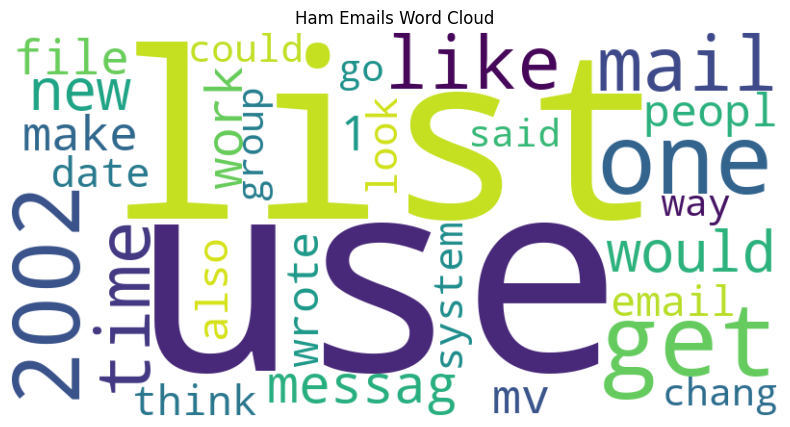

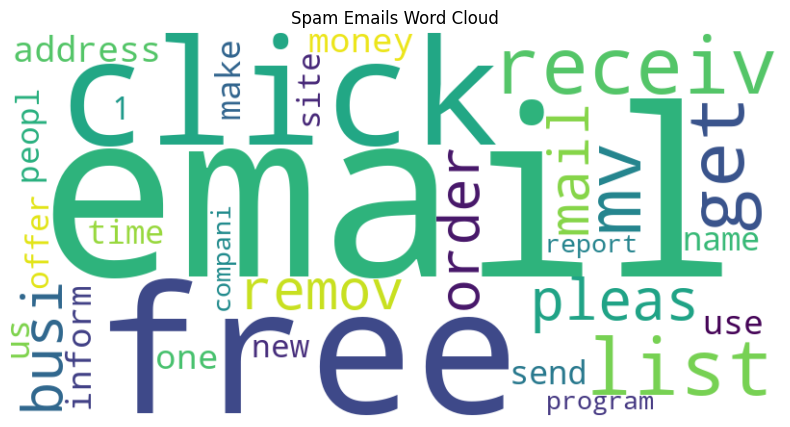

In [3]:
import pandas as pd
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt


# Function to generate a word cloud from a DataFrame
def generate_wordcloud(dataframe, title):
    # Convert DataFrame to dictionary
    data_dict = dataframe.set_index('Word')['Frequency'].to_dict()
    
    # Initialize WordCloud object
    wc = WordCloud(width=800, height=400, max_words=200, background_color='white')
    
    # Generate WordCloud
    wc.generate_from_frequencies(data_dict)
    
    # Plotting
    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.title(title)
    plt.axis('off')
    plt.show()

# Generate word cloud for 'ham' emails
generate_wordcloud(swh_df, 'Ham Emails Word Cloud')

# Generate word cloud for 'spam' emails
generate_wordcloud(sws_df, 'Spam Emails Word Cloud')


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, BaggingClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import cross_val_score
import numpy as np
import pandas as pd

#Initializes TF-IDF Vectorizer with a limit of 3000 features to transform text data into a matrix of TF-IDF values.
# This process emphasizes words that are important and unique to documents, making it crucial for analyzing and classifying email content effectively.
tfidf = TfidfVectorizer(max_features=3000)
#Setting feature variable as matrix of TF-IDF values derived from our transformed text column
#Each row in X represents an email, and each column represents one of up to 3000 most important words across all emails based on TF-IDF scores
X = tfidf.fit_transform(emails_df['trfm_text']).toarray()
y = emails_df['Classification'].map({'Ham': 0, 'Spam': 1}).values
# Step 2: Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Models to train
models = {
    "Logistic Regression": LogisticRegression(),
    "LDA": LinearDiscriminantAnalysis(),
    "QDA": QuadraticDiscriminantAnalysis(), 
    "Decision Tree": DecisionTreeClassifier(),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Bagging Classifier": BaggingClassifier(),
    "Extra Trees": ExtraTreesClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "XGBoost": XGBClassifier(eval_metric='logloss')
}

# Step 3: Training and evaluating models
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    results[name] = accuracy
   

# Step 4: Displaying Results for training model
print("\nModel performance summary:")
for name, accuracy in results.items():
    print(f"{name}: {accuracy:.4f}")

# Step 5: Training with cross-validation 
    results = {}
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5)  # 5-fold cross-validation
    accuracy = scores.mean()
    results[name] = accuracy

# Step 4: Displaying Results for cross-validation
print("\nCross-Validation:")
for name, accuracy in results.items():
    print(f"{name}: {accuracy:.4f}")


C:\Users\Zohd\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\discriminant_analysis.py:935: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")



Model performance summary:
Logistic Regression: 0.9835
LDA: 0.9872
QDA: 0.9718
SVC: 0.9955
Multinomial Naive Bayes: 0.9786
Decision Tree: 0.9857
K-Nearest Neighbors: 0.6490
Random Forest: 0.9959
AdaBoost: 0.9647
Bagging Classifier: 0.9850
Extra Trees: 0.9955
Gradient Boosting: 0.9714
XGBoost: 0.9936


C:\Users\Zohd\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\discriminant_analysis.py:935: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")
C:\Users\Zohd\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\discriminant_analysis.py:935: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")
C:\Users\Zohd\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\discriminant_analysis.py:935: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")
C:\Users\Zohd\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\discriminant_analysis.py:935: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")
C:\Users\Zohd\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\discriminant_analysis.py:935: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")



Cross-Validation:
Logistic Regression: 0.9772
LDA: 0.9682
QDA: 0.9702
SVC: 0.9853
Multinomial Naive Bayes: 0.9709
Decision Tree: 0.9611
K-Nearest Neighbors: 0.8932
Random Forest: 0.9804
AdaBoost: 0.9498
Bagging Classifier: 0.9626
Extra Trees: 0.9841
Gradient Boosting: 0.9457
XGBoost: 0.9738
